# Review Sentiment Analysis and Moderation Model

## Project Overview

This project builds a machine learning model that classifies customer reviews as **positive** or **negative** using Natural Language Processing (NLP).

The workflow includes:

- Dataset inspection
- Text data cleaning
- Class distribution analysis
- TF-IDF text vectorization
- Model training and comparison
- Model evaluation using accuracy, precision, recall, and F1-score
- Saving the best model
- Building a prediction function
- Adding simple review moderation logic


## 1. Import Libraries

We begin by importing the libraries needed for data handling, visualization, text vectorization, model training, evaluation, and saving the final model.

In [22]:
# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

# Model saving
import joblib
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
print('Libraries imported successfully!')

Libraries imported successfully!


## 2. Load the Dataset

The dataset contains two main columns:

- `review`: the customer review text
- `class`: the sentiment label, where `1` represents positive sentiment and `0` represents negative sentiment

In [23]:
# Load dataset
from google.colab import files
uploaded = files.upload()

df = pd.read_csv('TestReviews.csv')

df.head()

Saving TestReviews.csv to TestReviews (2).csv


,review,class
0,Fantastic spot for an even or a quite cocktail...,1
1,"Love, love, love the calamari. It's so good an...",1
2,"Love this place. Stiff martinis and cocktails,...",1
3,It's everything a great cocktail bar should be...,1
4,"I came here before a pirates game, so it was a...",1


## 3. Dataset Overview

This section checks the dataset shape, columns, missing values, duplicate rows, and class distribution.

In [24]:
print('Dataset shape:', df.shape)
print('\nColumns:', df.columns.tolist())
print('\nMissing values:')
print(df.isnull().sum())
print('\nDuplicate rows:', df.duplicated().sum())
print('\nClass distribution:')
print(df['class'].value_counts())

Dataset shape: (4321, 2)

Columns: ['review', 'class']

Missing values:
review    0
class     0
dtype: int64

Duplicate rows: 173

Class distribution:
class
1    2989
0    1332
Name: count, dtype: int64


## 4. Class Distribution

Before training, it is important to inspect whether the classes are balanced. If one class dominates, accuracy alone can be misleading.

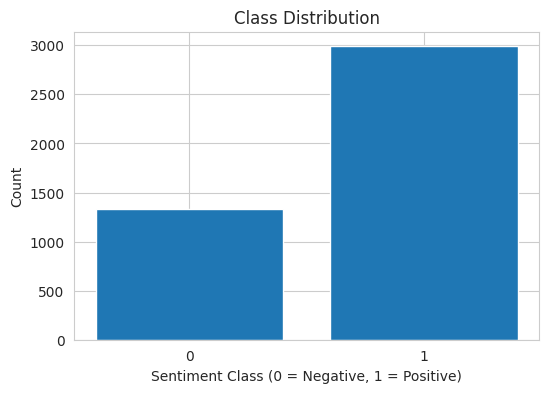

,proportion
class,
1,69.173802
0,30.826198


In [25]:
class_counts = df['class'].value_counts().sort_index()

plt.figure(figsize=(6, 4))
plt.bar(class_counts.index.astype(str), class_counts.values)
plt.title('Class Distribution')
plt.xlabel('Sentiment Class (0 = Negative, 1 = Positive)')
plt.ylabel('Count')
plt.show()

class_percentage = df['class'].value_counts(normalize=True) * 100
class_percentage

### Observation

The dataset contains more positive reviews than negative reviews. This means the dataset is moderately imbalanced, so model evaluation should consider **precision, recall, and F1-score**, not only accuracy.

## 5. Text Cleaning

The dataset does not contain missing values, but it is still important to remove empty reviews and exact duplicate records.

Duplicate reviews may cause the model to learn repeated patterns too strongly, so exact duplicates are removed.

In [26]:
# Remove empty reviews
initial_rows = df.shape[0]
df = df[df['review'].astype(str).str.strip() != '']

# Remove exact duplicate rows
df = df.drop_duplicates().reset_index(drop=True)

print('Rows before cleaning:', initial_rows)
print('Rows after cleaning:', df.shape[0])
print('Rows removed:', initial_rows - df.shape[0])
print('\nMissing values after cleaning:')
print(df.isnull().sum())

Rows before cleaning: 4321
Rows after cleaning: 4147
Rows removed: 174

Missing values after cleaning:
review    0
class     0
dtype: int64


## 6. Review Length Analysis

Review length can affect text modeling because very short reviews may contain limited context, while very long reviews may contain mixed opinions.

In [27]:
df['review_length'] = df['review'].astype(str).apply(len)
df['word_count'] = df['review'].astype(str).apply(lambda x: len(x.split()))

df[['review_length', 'word_count']].describe()

,review_length,word_count
count,4147.000000,4147.000000
mean,680.037376,125.314444
std,614.370476,113.800343
min,6.000000,1.000000
25%,271.000000,50.000000
50%,507.000000,93.000000
75%,883.000000,162.000000
max,4935.000000,972.000000


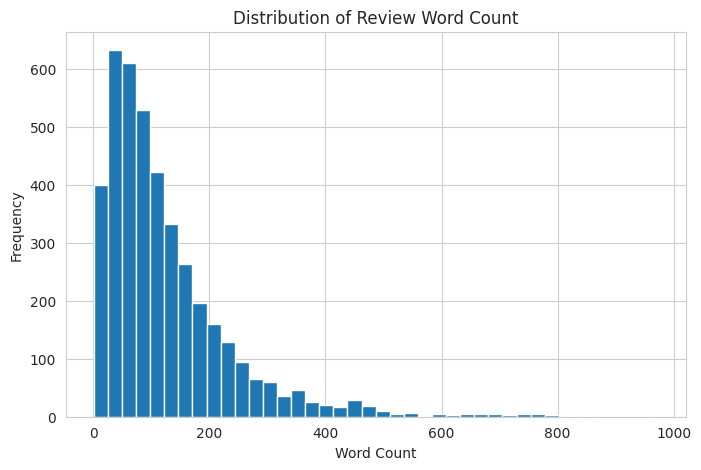

In [28]:
plt.figure(figsize=(8, 5))
plt.hist(df['word_count'], bins=40)
plt.title('Distribution of Review Word Count')
plt.xlabel('Word Count')
plt.ylabel('Frequency')
plt.show()

## 7. Define Features and Target

The review text is used as the input feature, while the class label is used as the target variable.

In [29]:
X = df['review'].astype(str)
y = df['class']

print('Feature size:', X.shape)
print('Target size:', y.shape)

Feature size: (4147,)
Target size: (4147,)


## 8. Train-Test Split

The dataset is split into training and testing sets. Stratification is used to preserve the same class distribution in both sets.

In [30]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print('Training size:', X_train.shape)
print('Testing size:', X_test.shape)
print('\nTraining class distribution:')
print(y_train.value_counts(normalize=True) * 100)
print('\nTesting class distribution:')
print(y_test.value_counts(normalize=True) * 100)

Training size: (3317,)
Testing size: (830,)

Training class distribution:
class
1    68.977992
0    31.022008
Name: proportion, dtype: float64

Testing class distribution:
class
1    69.036145
0    30.963855
Name: proportion, dtype: float64


## 9. Text Vectorization with TF-IDF

Machine learning models cannot directly understand raw text. Therefore, the reviews are converted into numerical features using **TF-IDF Vectorization**.

TF-IDF gives higher importance to words that are meaningful in a review while reducing the impact of very common words.

In [31]:
vectorizer = TfidfVectorizer(
    stop_words='english',
    max_features=5000,
    ngram_range=(1, 2),
    min_df=2
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print('Training TF-IDF shape:', X_train_tfidf.shape)
print('Testing TF-IDF shape:', X_test_tfidf.shape)

Training TF-IDF shape: (3317, 5000)
Testing TF-IDF shape: (830, 5000)


## 10. Model Training and Comparison

Two models are compared:

1. **Logistic Regression** — a strong baseline for text classification
2. **Multinomial Naive Bayes** — commonly used for text classification tasks

Because the dataset is moderately imbalanced, the models are compared using accuracy, precision, recall, F1-score, and macro F1-score.

In [32]:
models = {
    'Logistic Regression': LogisticRegression(
        max_iter=1000,
        class_weight='balanced',
        random_state=42
    ),
    'Multinomial Naive Bayes': MultinomialNB()
}

results = []
trained_models = {}

for model_name, model in models.items():
    model.fit(X_train_tfidf, y_train)
    y_pred = model.predict(X_test_tfidf)

    results.append({
        'Model': model_name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred),
        'Macro F1-Score': f1_score(y_test, y_pred, average='macro')
    })

    trained_models[model_name] = model

results_df = pd.DataFrame(results).sort_values(by='Macro F1-Score', ascending=False)
results_df

,Model,Accuracy,Precision,Recall,F1-Score,Macro F1-Score
0,Logistic Regression,0.93253,0.954306,0.947644,0.950963,0.921428
1,Multinomial Naive Bayes,0.90241,0.884375,0.987784,0.933223,0.876008


### Model Selection

The best model is selected using **Macro F1-Score**, because this metric gives balanced attention to both positive and negative classes.

In [33]:
best_model_name = results_df.iloc[0]['Model']
best_model = trained_models[best_model_name]

print('Best model:', best_model_name)

Best model: Logistic Regression


## 11. Final Model Evaluation

The best model is evaluated using a classification report and confusion matrix.

In [34]:
y_pred = best_model.predict(X_test_tfidf)

print('Accuracy:', accuracy_score(y_test, y_pred))
print('\nClassification Report:\n')
print(classification_report(y_test, y_pred, target_names=['Negative', 'Positive']))
print('\nConfusion Matrix:\n')
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.9325301204819277

Classification Report:

              precision    recall  f1-score   support

    Negative       0.89      0.90      0.89       257
    Positive       0.95      0.95      0.95       573

    accuracy                           0.93       830
   macro avg       0.92      0.92      0.92       830
weighted avg       0.93      0.93      0.93       830


Confusion Matrix:

[[231  26]
 [ 30 543]]


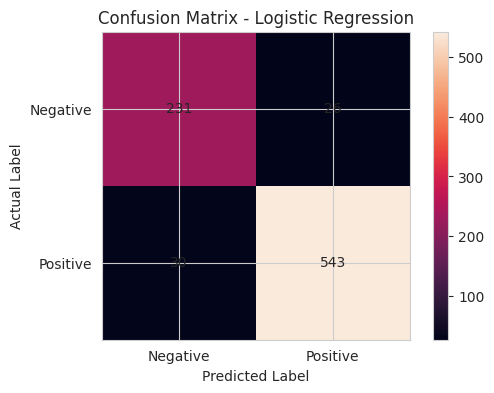

In [35]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))
plt.imshow(cm)
plt.title(f'Confusion Matrix - {best_model_name}')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.xticks([0, 1], ['Negative', 'Positive'])
plt.yticks([0, 1], ['Negative', 'Positive'])

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha='center', va='center')

plt.colorbar()
plt.show()

### Evaluation Interpretation

The model performs well overall, for this project, F1-score and recall are especially useful because they show how well the model identifies both negative and positive reviews.

## 12. Save the Best Model and Vectorizer

The trained model and TF-IDF vectorizer are saved so they can be reused later without retraining.

In [36]:
joblib.dump(best_model, 'sentiment_model.pkl')
joblib.dump(vectorizer, 'tfidf_vectorizer.pkl')

print('Model saved as sentiment_model.pkl')
print('Vectorizer saved as tfidf_vectorizer.pkl')

Model saved as sentiment_model.pkl
Vectorizer saved as tfidf_vectorizer.pkl


## 13. Prediction Function

This function loads the saved model and vectorizer, transforms a new review, and predicts whether the review is negative or positive.

In [37]:
def predict_sentiment(text):
    loaded_model = joblib.load('sentiment_model.pkl')
    loaded_vectorizer = joblib.load('tfidf_vectorizer.pkl')

    text_vector = loaded_vectorizer.transform([text])
    prediction = loaded_model.predict(text_vector)[0]
    probability = loaded_model.predict_proba(text_vector)[0]

    label = 'Positive' if prediction == 1 else 'Negative'

    return {
        'review': text,
        'predicted_class': int(prediction),
        'sentiment': label,
        'negative_probability': round(float(probability[0]), 4),
        'positive_probability': round(float(probability[1]), 4)
    }

## 14. Prediction Examples

Testing the model with new review examples helps demonstrate how the model behaves on positive, negative, and neutral/mixed reviews.

In [38]:
test_reviews = [
    'This service was absolutely amazing',
    'This place is terrible and slow',
    'The food was terrible but the staff were friendly',
    'The service was okay',
    'service was not bad',
    'I would never come back here again'
]

for review in test_reviews:
    print(predict_sentiment(review))

{'review': 'This service was absolutely amazing', 'predicted_class': 1, 'sentiment': 'Positive', 'negative_probability': 0.2319, 'positive_probability': 0.7681}
{'review': 'This place is terrible and slow', 'predicted_class': 0, 'sentiment': 'Negative', 'negative_probability': 0.88, 'positive_probability': 0.12}
{'review': 'The food was terrible but the staff were friendly', 'predicted_class': 0, 'sentiment': 'Negative', 'negative_probability': 0.5708, 'positive_probability': 0.4292}
{'review': 'The service was okay', 'predicted_class': 0, 'sentiment': 'Negative', 'negative_probability': 0.7638, 'positive_probability': 0.2362}
{'review': 'service was not bad', 'predicted_class': 0, 'sentiment': 'Negative', 'negative_probability': 0.9448, 'positive_probability': 0.0552}
{'review': 'I would never come back here again', 'predicted_class': 1, 'sentiment': 'Positive', 'negative_probability': 0.4555, 'positive_probability': 0.5445}


## 15. Simple Review Moderation Logic

A simple moderation layer is added to flag reviews that contain abusive keywords or strongly negative sentiment.

This is not a replacement for a full moderation system, but it demonstrates how sentiment analysis can support review monitoring.

In [39]:
abusive_keywords = ['scam', 'fraud', 'idiot', 'stupid', 'useless', 'trash', 'fake']

def moderate_review(text, negative_threshold=0.70):
    result = predict_sentiment(text)
    lower_text = text.lower()
    contains_abuse = any(word in lower_text for word in abusive_keywords)
    strong_negative = (
        result['predicted_class'] == 0 and
        result['negative_probability'] >= negative_threshold
    )

    if contains_abuse and strong_negative:
        flag = True
        reason = 'Abusive language and strong negative sentiment detected'
    elif contains_abuse:
        flag = True
        reason = 'Abusive language detected'
    elif strong_negative:
        flag = True
        reason = 'Strong negative sentiment detected'
    else:
        flag = False
        reason = 'No moderation issue detected'

    return {
        'review': text,
        'sentiment': result['sentiment'],
        'negative_probability': result['negative_probability'],
        'positive_probability': result['positive_probability'],
        'flagged': flag,
        'reason': reason
    }

In [40]:
moderation_examples = [
    'This business is a scam and useless',
    'The service was slow',
    'The food was terrible but the staff were friendly',
    'The experience was wonderful and I will return',
    'okay'
]

for review in moderation_examples:
    print(moderate_review(review))

{'review': 'This business is a scam and useless', 'sentiment': 'Negative', 'negative_probability': 0.6945, 'positive_probability': 0.3055, 'flagged': True, 'reason': 'Abusive language detected'}
{'review': 'The service was slow', 'sentiment': 'Negative', 'negative_probability': 0.6827, 'positive_probability': 0.3173, 'flagged': False, 'reason': 'No moderation issue detected'}
{'review': 'The food was terrible but the staff were friendly', 'sentiment': 'Negative', 'negative_probability': 0.5708, 'positive_probability': 0.4292, 'flagged': False, 'reason': 'No moderation issue detected'}
{'review': 'The experience was wonderful and I will return', 'sentiment': 'Positive', 'negative_probability': 0.313, 'positive_probability': 0.687, 'flagged': False, 'reason': 'No moderation issue detected'}
{'review': 'okay', 'sentiment': 'Negative', 'negative_probability': 0.6494, 'positive_probability': 0.3506, 'flagged': False, 'reason': 'No moderation issue detected'}


## 16. Limitations

This project is a strong baseline, but there are some limitations:

- The dataset is moderately imbalanced, with more positive reviews than negative reviews.
- Neutral reviews may be misclassified because the dataset only contains binary labels.
- Some mixed reviews contain both positive and negative language, which can confuse the model.
- The moderation system is keyword-based and simple; a more advanced system would require a larger abusive-language dataset.
- More advanced NLP models such as BERT could be explored in future work.

## 17. Conclusion

This project developed a sentiment analysis model for customer reviews using Python and machine learning.

The workflow covered text data cleaning, TF-IDF vectorization, model comparison, evaluation, model saving, prediction testing, and simple review moderation.

The final model provides a useful baseline for classifying customer reviews as positive or negative, while the moderation logic demonstrates how sentiment analysis can support practical review monitoring.